## Imports



In [1]:
import torch
import matplotlib.pyplot as plt
import numpy as np
from tqdm.notebook import tqdm
import seaborn as sns
from performance_boosting import PBClosedLoop
from ren import ContractiveREN
from robot import RobotPlant, StabilizedRobot, PDController
from plot_functions import plot_pb_trajectories, plot_distance_tube
from dataset import generate_random_batch
from losses_and_wrappers import PBLoss, CVaRLossWrapper, SplitCVaRLossWrapper, HardConstraintCVaRLossWrapper, ERMWrapper

## Simulation parameters

In [2]:
#setup device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
#TODO: to device

#seed
seed = 1

#dataset parameters
gmm =True
gaussian = not gmm
if gaussian:
    x0_centers=[[-1.0, -1.0]]
    x0_stds=[0.2]
    x0_probs = None
elif gmm:
    x0_centers=[
        [-1.0, -1.0], # Center 1 (Easy)
        [ 1., -1.],  # Center 2 (Hard)
        [ -1., 1.],  # Center 3
    ]
    x0_stds=[0.2, 0.1, 0.5]  #  set different spreads per mode!
    x0_probs=[0.4, 0.2, 0.4] # Weights

noise_std = 0.

#controller parameters
x_target = torch.zeros(4)
kp = 1.
ki = 1.

#physics parameters
n_agents = 1
state_dim = 4
input_dim = 2
dt = 0.05

#nominal model parameters
b_nom = 1
m_nom = 1
b2_nom = 0.2

#simulator parameters
b_sim = 1
m_sim = 1
b2_sim = 0.2

#ren parameters
initialization_std = 0.01
dim_internal = 4
dim_nl = 4

# --- 2. Loss Parameters (Q and R) ---
# Base Q for 1 agent: Penalize pos_x, pos_y, vel_x, vel_y shape (4, 4)
lambda_x = 10
Q_agent = torch.diag(torch.tensor([1.0, 1.0, 1.0, 1.0])) * lambda_x
# Expand Q for N agents (Block Diagonal): (4 * n_agents, 4 * n_agents)
Q = torch.kron(torch.eye(n_agents), Q_agent)

# Base R for 1 agent: Penalize force_x, force_y shape (2, 2)
lambda_u = 0.01
R_agent = torch.eye(2) * lambda_u
# Expand R for N agents: (2 * n_agents, 2 * n_agents)
R = torch.kron(torch.eye(n_agents), R_agent)

#lamnda as hyperparameter
lambda_decoupling = 1

#safety threshold for lagrangian
tau_safe_bar = 0  # <--- DESIRED SAFETY THRESHOLD

# Weight for obstacle avoidance
lambda_obs = 50.0
#type of tracking and collision avoidance loss
track_mode='quadratic'
coll_mode = 'shifted_rbf'

# --- 3. Obstacles Parameters ---
obs_centers = [torch.tensor([0.5, -0.5]), torch.tensor([-0.5, 0.])]

# Obstacle 1 is wide [0.6, 0.2]
# Obstacle 2 is tall [0.1, 0.5]
obs_radii = [[0.25], [0.1, 0.5]]

safety_margin = 0.05
obs_radii_safe = [[r + safety_margin for r in obs] for obs in obs_radii]

# --- 4. Target State: All agents to go to origin (0,0) with 0 velocity.
x_target = torch.zeros(4 * n_agents)

#------ 5. Wrapper_parameters----------
decoupled_metrics = True
cvar_wrapper = True
conditional_training = False
#true certification goals
alpha_true = 0.05       # You want the real-world worst 5% targets 95% confidence
delta = 0.01            # With 99% confidence
m_cert = 2000           # Size of your final certification batch
#Calculate the penalty term (epsilon)
if conditional_training:
    epsilon_cert = np.sqrt(np.log(2 / delta) / (2 * m_cert))
else:
    epsilon_cert = 0
# Shift training alpha!
alpha_train = alpha_true - epsilon_cert

#--------6. Training parameters------------
num_training_steps = 500

log_interval = 1 # Evaluate and print every log_interval steps
batch_size = 200
horizon = 500
lr = 0.001

#---------7. Validation and test------------
num_val_samples = 500
num_test_samples = 2000

## Set seed

In [3]:
seed = seed  # Choose any fixed number
torch.manual_seed(seed)
np.random.seed(seed)

## Fixed validation set

In [4]:
# Fixed validation set to evaluate true convergence
fixed_val_w = generate_random_batch(batch_size = num_val_samples, horizon = horizon, n_agents= n_agents, x0_centers=x0_centers, x0_stds=x0_stds, x0_probs = x0_probs, noise_std = noise_std, device = device)

## Simulator, nominal model and stabilizing controller

In [5]:
#Open loop real plant (unknown)
sim_OL_plant = RobotPlant(b = b_sim, b2 = b2_sim, m = m_sim, n_agents = n_agents).to(device)
#Open loop nominal model
nominal_OL_plant = RobotPlant(b = b_nom, b2 = b2_nom, m = m_nom, n_agents = n_agents).to(device)
#Proportional controller
base_controller = PDController(kp = kp, ki = ki, n_agents = n_agents).to(device)
#Stabilized real plant (closed loop of real plant and base controller) (unknown)
f_sim = StabilizedRobot(sim_OL_plant, base_controller).to(device)
#Stabilized nominal model (closed loop of nominal model and base controller) (I could use a different controller as long as this is a stable closed loop or if I use the base controller of the real plant I have to make sure it stabilizes my model as well)
f_nom = StabilizedRobot(nominal_OL_plant, base_controller).to(device)

#Freeze the physics/nominal models
for param in f_sim.parameters():
    param.requires_grad = False
for param in f_nom.parameters():
    param.requires_grad = False

## Empirical Risk Minimization training (no model mismatch)


### Define simulated model

In [6]:
#Ren
ren = ContractiveREN(dim_in=state_dim*n_agents, dim_out=input_dim*n_agents, dim_internal=dim_internal, dim_nl=dim_nl, initialization_std=initialization_std).to(device)

#Closed loop of Performance boosting controller and simulator of closed loop
PB_closed_loop_sim = PBClosedLoop(ren, f_sim, f_nom).to(device)

### Training loop


In [7]:
#Instantiate loss and Move to Device
loss_fn = PBLoss(x_target, Q, R, lambda_obs, obs_centers, obs_radii_safe=obs_radii_safe, n_agents=n_agents, track_mode=track_mode, coll_mode = coll_mode)
loss_fn.to(device) #Moves Q, R, target, and obstacles to GPU
loss_wrapper = ERMWrapper(loss_fn)

optimizer = torch.optim.Adam(PB_closed_loop_sim.parameters(), lr=lr)

# Lists for plotting
train_losses = []
val_losses = []
val_loss_targets = []
val_loss_us = []
val_loss_obss = []

# Only store the very last batch's trajectories for plotting to save RAM
last_traj_x_val = None
last_traj_u_val = None
last_traj_w_hat_val = None

print(f"Starting online training on {device}...")

# Use tqdm for a nice progress bar
pbar = tqdm(range(num_training_steps), desc="Training Steps")

for step in pbar:
    # --- TRAINING PHASE ---
    PB_closed_loop_sim.train()
    optimizer.zero_grad()

    # 1. Generate fresh data
    batch_w = generate_random_batch(batch_size = batch_size, horizon = horizon, n_agents= n_agents, x0_centers=x0_centers, x0_stds=x0_stds, x0_probs = x0_probs, noise_std = noise_std, device = device)

    # 2. Run Sim & Compute Loss
    traj_x_train, traj_u_train, traj_w_hat_train = PB_closed_loop_sim.run(batch_w)
    loss, _, _, _ = loss_wrapper(traj_x_train, traj_u_train)

    # 3. Backprop
    loss.backward()
    optimizer.step()

    # --- VALIDATION & LOGGING ---
    if (step + 1) % log_interval == 0:
        PB_closed_loop_sim.eval()

        with torch.no_grad():
            # Evaluate on FIXED validation set
            traj_x_val, traj_u_val, traj_w_hat_val = PB_closed_loop_sim.run(fixed_val_w)
            val_loss, val_target, val_u, val_obs = loss_wrapper(traj_x_val, traj_u_val)

        # Update lists for plotting
        train_losses.append(loss.item())
        val_losses.append(val_loss.item())
        # Track individual components
        val_loss_targets.append(val_target.item())
        val_loss_us.append(val_u.item())
        val_loss_obss.append(val_obs.item())

        # Update progress bar metrics (adding obstacle loss here is usually very helpful for quick debugging)
        pbar.set_postfix({
            'Train Loss': f"{loss.item():.4f}",
            'Val Loss': f"{val_loss.item():.4f}",
            'Val Obs': f"{val_obs:.4f}"
        })

    if step == num_training_steps - 1:
        last_traj_x_val = traj_x_val.detach().cpu()
        last_traj_u_val = traj_u_val.detach().cpu()
        last_traj_w_hat_val = traj_w_hat_val.detach().cpu()

Starting online training on cpu...


Training Steps:   0%|          | 0/500 [00:00<?, ?it/s]

### Plots


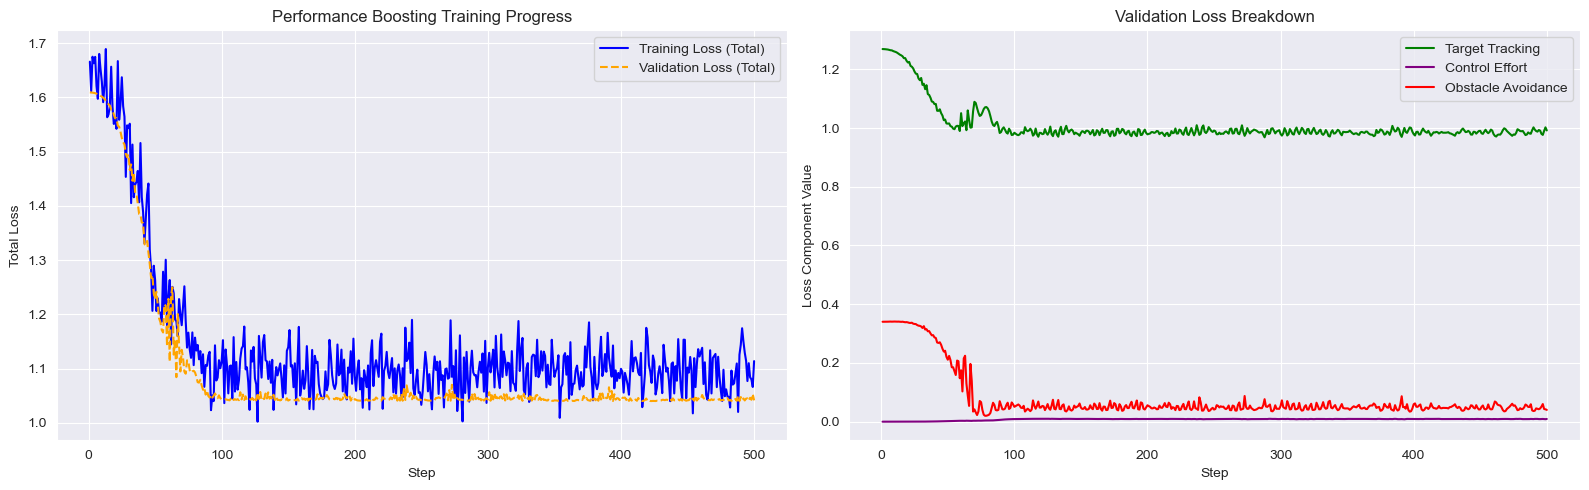

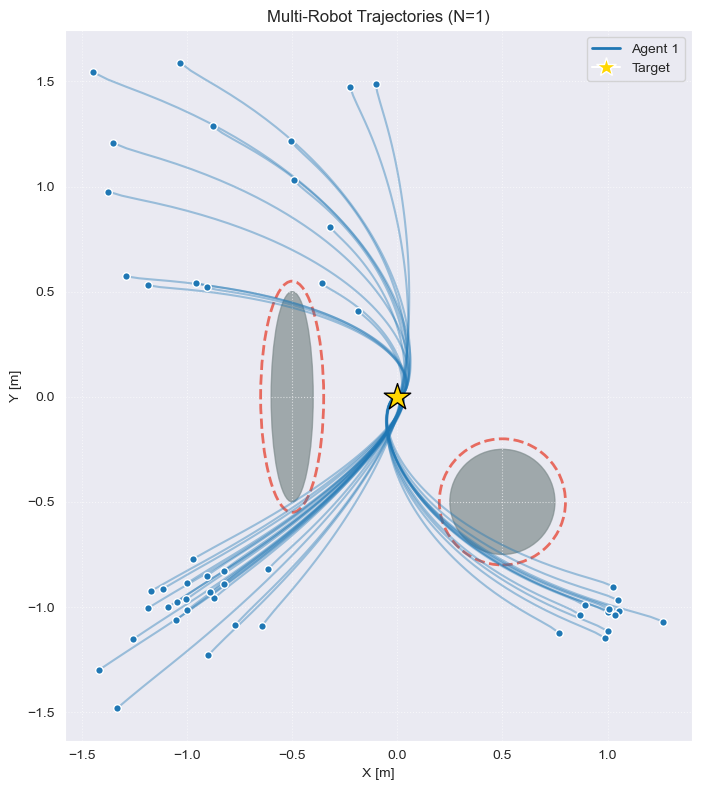

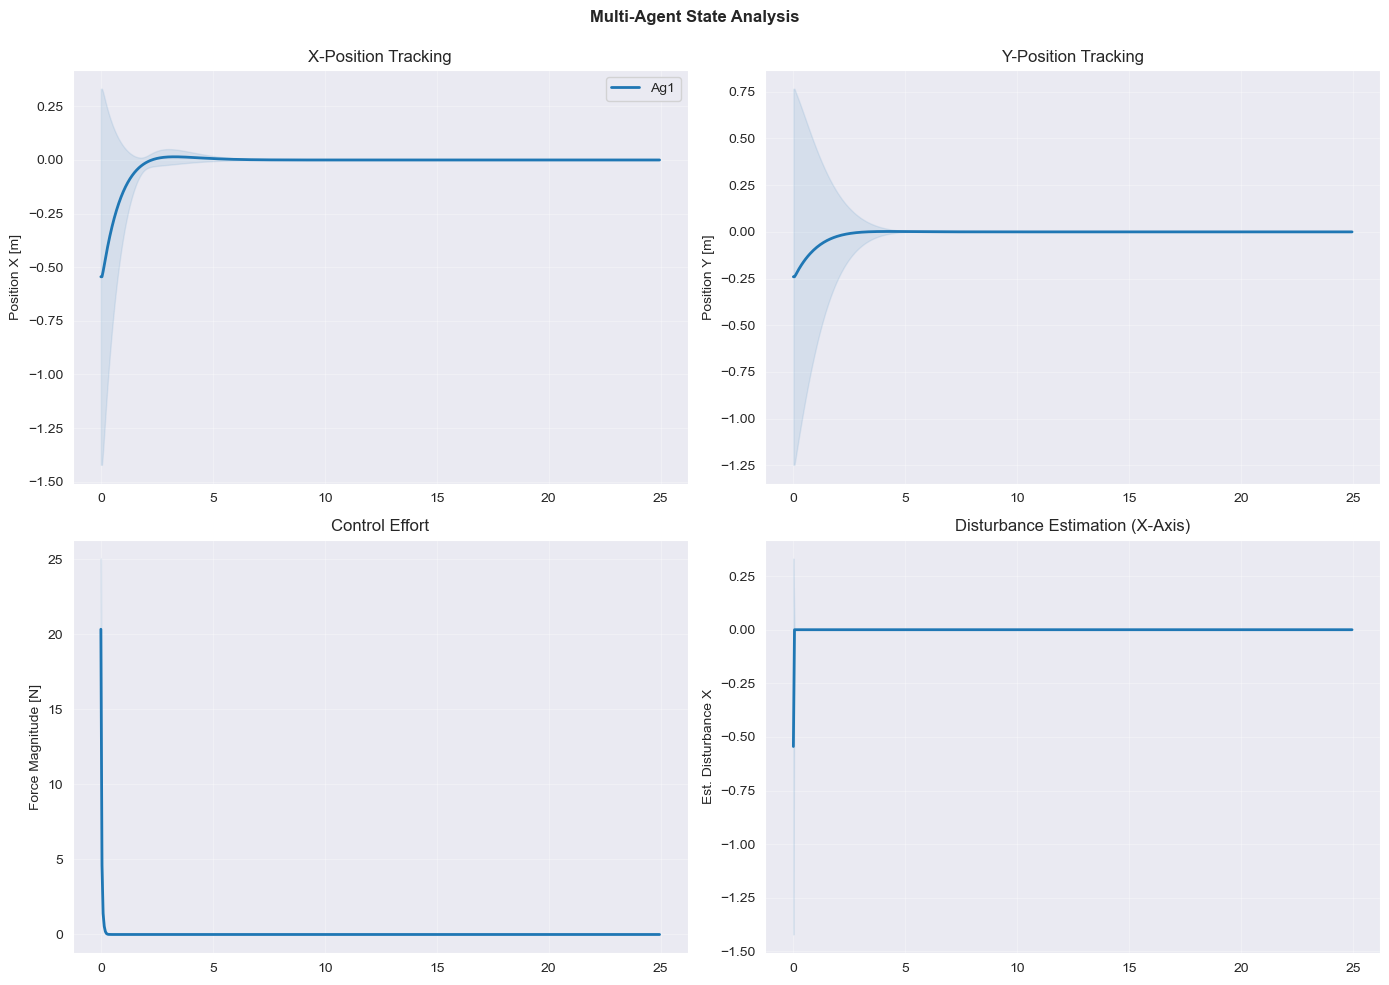

In [8]:
# --- PLOTTING ---
steps = range(log_interval, num_training_steps + 1, log_interval)

# Create a 1x2 grid of subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

# Plot 1: Total Traing vs Validation Loss
ax1.plot(steps, train_losses, label='Training Loss (Total)', color='blue')
ax1.plot(steps, val_losses, label='Validation Loss (Total)', color='orange', linestyle='--')
ax1.set_xlabel('Step')
ax1.set_ylabel('Total Loss')
ax1.set_title('Performance Boosting Training Progress')
ax1.legend()
ax1.grid(True)

# Plot 2: Validation Loss Breakdown
ax2.plot(steps, val_loss_targets, label='Target Tracking', color='green')
ax2.plot(steps, val_loss_us, label='Control Effort', color='purple')
ax2.plot(steps, val_loss_obss, label='Obstacle Avoidance', color='red')
ax2.set_xlabel('Step')
ax2.set_ylabel('Loss Component Value')
ax2.set_title('Validation Loss Breakdown')
ax2.legend()
ax2.grid(True)

# Adjust layout to prevent overlap and show
plt.tight_layout()
plt.show()

plot_pb_trajectories(
    traj_x=last_traj_x_val,
    traj_u=last_traj_u_val,
    traj_w_hat=traj_w_hat_val,
    x_target=x_target,
    obs_centers=obs_centers,
    obs_radii=obs_radii,
    obs_radii_safe = obs_radii_safe,
    dt=dt
)

## Quantile-oriented training

### Define simulated model

In [9]:
#Ren
ren_quantile = ContractiveREN(dim_in=state_dim*n_agents, dim_out=input_dim*n_agents, dim_internal=dim_internal, dim_nl=dim_nl, initialization_std=initialization_std).to(device)

#Closed loop of Performance boosting controller and simulator of closed loop
PB_closed_loop_sim_quantile = PBClosedLoop(ren_quantile, f_sim, f_nom).to(device)

### Training loop

In [10]:
#Instantiate metric and Move to Device
metric = PBLoss(x_target, Q, R, lambda_obs, obs_centers, obs_radii_safe=obs_radii_safe, n_agents=n_agents, track_mode=track_mode, coll_mode = coll_mode)

metric.to(device)  #Moves Q, R, target, and obstacles to GPU

# 1. Setup Loss Wrapper
if decoupled_metrics:
    loss_wrapper = SplitCVaRLossWrapper(alpha = alpha_train, lambda_decoupling = lambda_decoupling, metric=metric)
else:
    loss_wrapper = CVaRLossWrapper(alpha=alpha_train, metric=metric)
loss_wrapper.to(device) # Moves tau to GPU


# We must optimize controller and tau (threshold) simultaneously
optimizer = torch.optim.Adam(
    list(PB_closed_loop_sim_quantile.parameters()) + [loss_wrapper.tau],
    lr=lr
)

# Lists for plotting
train_losses = []
val_losses = []
val_loss_targets = []
val_loss_us = []
val_loss_obss = []

# Only store the very last batch's trajectories for plotting to save RAM
last_traj_x_train = None
last_traj_u_train = None
last_traj_w_hat_train = None

last_traj_x_val = None
last_traj_u_val = None
last_traj_w_hat_val = None

print(f"Starting online training on {device}...")

# Use tqdm for a nice progress bar
pbar = tqdm(range(num_training_steps), desc="CVaR Training Steps")

for step in pbar:
    PB_closed_loop_sim_quantile.train()
    optimizer.zero_grad()

    batch_w = generate_random_batch(batch_size = batch_size, horizon = horizon, n_agents= n_agents, x0_centers=x0_centers, x0_stds=x0_stds, x0_probs = x0_probs, noise_std = noise_std, device = device)

    traj_x_train, traj_u_train, traj_w_hat_train = PB_closed_loop_sim_quantile.run(batch_w)
    # Wrapper returns (loss, raw_costs)
    loss, _, _, _ = loss_wrapper(traj_x_train, traj_u_train)

    loss.backward()
    optimizer.step()

    if (step + 1) % log_interval == 0:
        PB_closed_loop_sim_quantile.eval()

        with torch.no_grad():
            traj_x_val, traj_u_val, traj_w_hat_val = PB_closed_loop_sim_quantile.run(fixed_val_w)
            val_loss, val_target, val_u, val_obs = loss_wrapper(traj_x_val, traj_u_val)

        train_losses.append(loss.item())
        val_losses.append(val_loss.item())
        # Track individual components
        val_loss_targets.append(val_target.item())
        val_loss_us.append(val_u.item())
        val_loss_obss.append(val_obs.item())

        # Update progress bar metrics (adding obstacle loss here is usually very helpful for quick debugging)
        pbar.set_postfix({
            'CVaR Train': f"{loss.item():.4f}",
            'CVaR Val': f"{val_loss.item():.4f}",
            'Tau': f"{loss_wrapper.tau.item():.4f}",
            'Val Obs': f"{val_obs:.4f}"
        })

    if step == num_training_steps - 1:
        last_traj_x_val = traj_x_val.detach().cpu()
        last_traj_u_val = traj_u_val.detach().cpu()
        last_traj_w_hat_val = traj_w_hat_val.detach().cpu()

Starting online training on cpu...


CVaR Training Steps:   0%|          | 0/500 [00:00<?, ?it/s]

### Plots


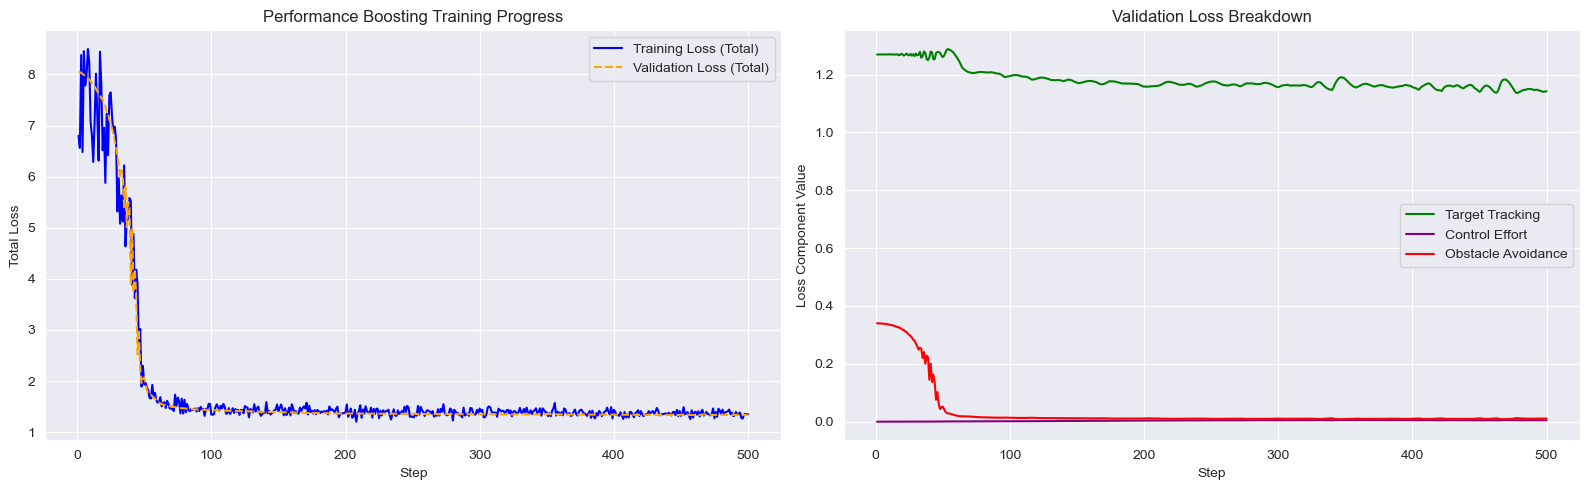

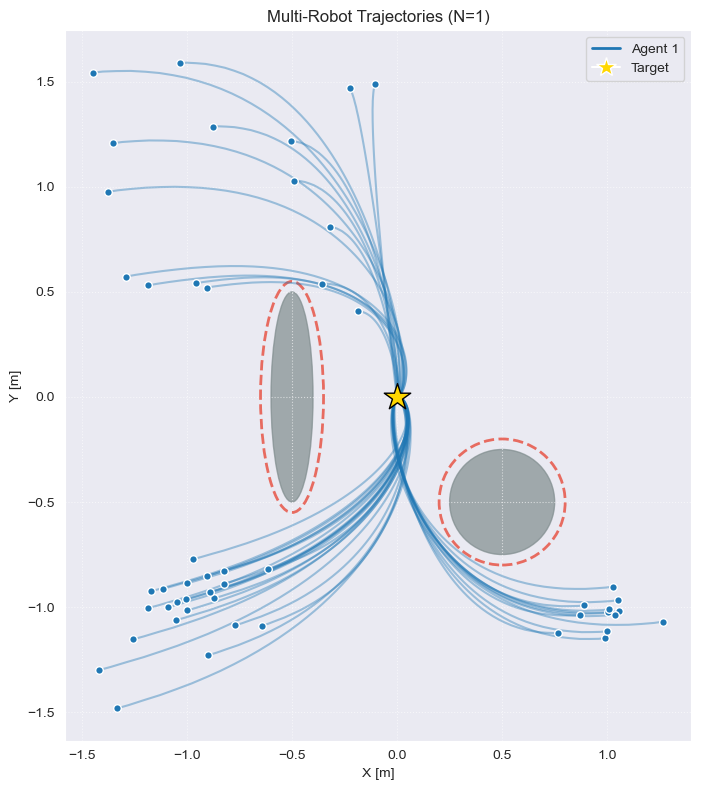

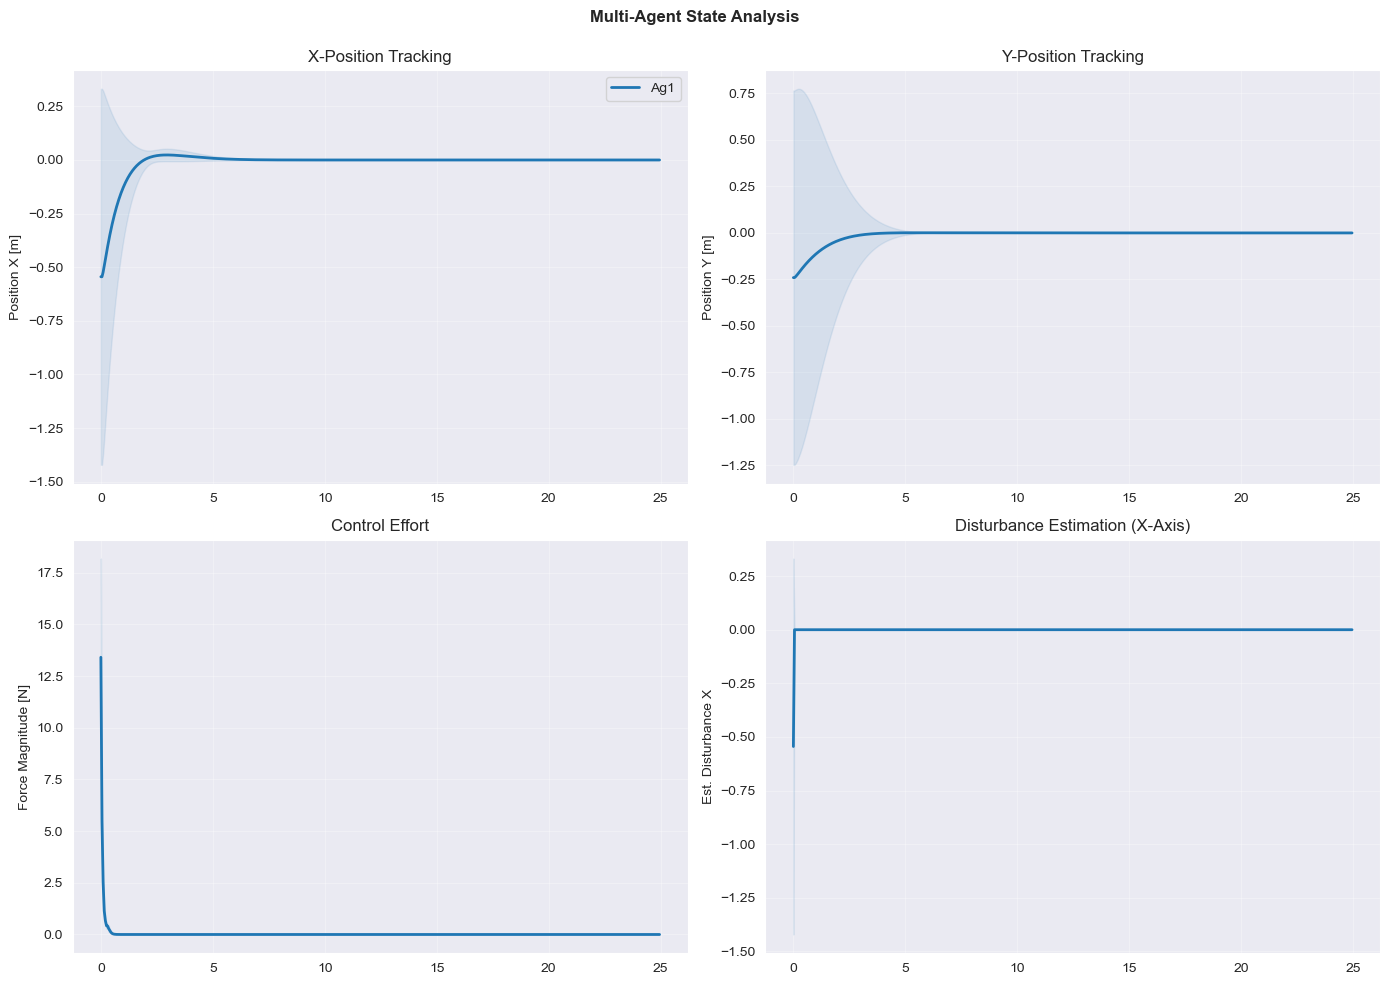

In [11]:
# --- PLOTTING ---
steps = range(log_interval, num_training_steps + 1, log_interval)

# Create a 1x2 grid of subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

# Plot 1: Total Traing vs Validation Loss
ax1.plot(steps, train_losses, label='Training Loss (Total)', color='blue')
ax1.plot(steps, val_losses, label='Validation Loss (Total)', color='orange', linestyle='--')
ax1.set_xlabel('Step')
ax1.set_ylabel('Total Loss')
ax1.set_title('Performance Boosting Training Progress')
ax1.legend()
ax1.grid(True)

# Plot 2: Validation Loss Breakdown
ax2.plot(steps, val_loss_targets, label='Target Tracking', color='green')
ax2.plot(steps, val_loss_us, label='Control Effort', color='purple')
ax2.plot(steps, val_loss_obss, label='Obstacle Avoidance', color='red')
ax2.set_xlabel('Step')
ax2.set_ylabel('Loss Component Value')
ax2.set_title('Validation Loss Breakdown')
ax2.legend()
ax2.grid(True)

# Adjust layout to prevent overlap and show
plt.tight_layout()
plt.show()

plot_pb_trajectories(
    traj_x=last_traj_x_val,
    traj_u=last_traj_u_val,
    traj_w_hat=last_traj_w_hat_val,
    x_target=x_target,
    obs_centers=obs_centers,
    obs_radii=obs_radii,
    obs_radii_safe = obs_radii_safe,
    dt=dt
)

## Training Lagrangian

### Define simulated model


In [12]:
#Ren
ren_lagrangian = ContractiveREN(dim_in=state_dim*n_agents, dim_out=input_dim*n_agents, dim_internal=dim_internal, dim_nl=dim_nl, initialization_std=initialization_std).to(device)

#Closed loop of Performance boosting controller and simulator of closed loop
PB_closed_loop_sim_lagrangian = PBClosedLoop(ren_lagrangian, f_sim, f_nom).to(device)

### Training loop

Starting Formulation 3 Dual-Ascent training on cpu...


Hard Constrained Training:   0%|          | 0/500 [00:00<?, ?it/s]

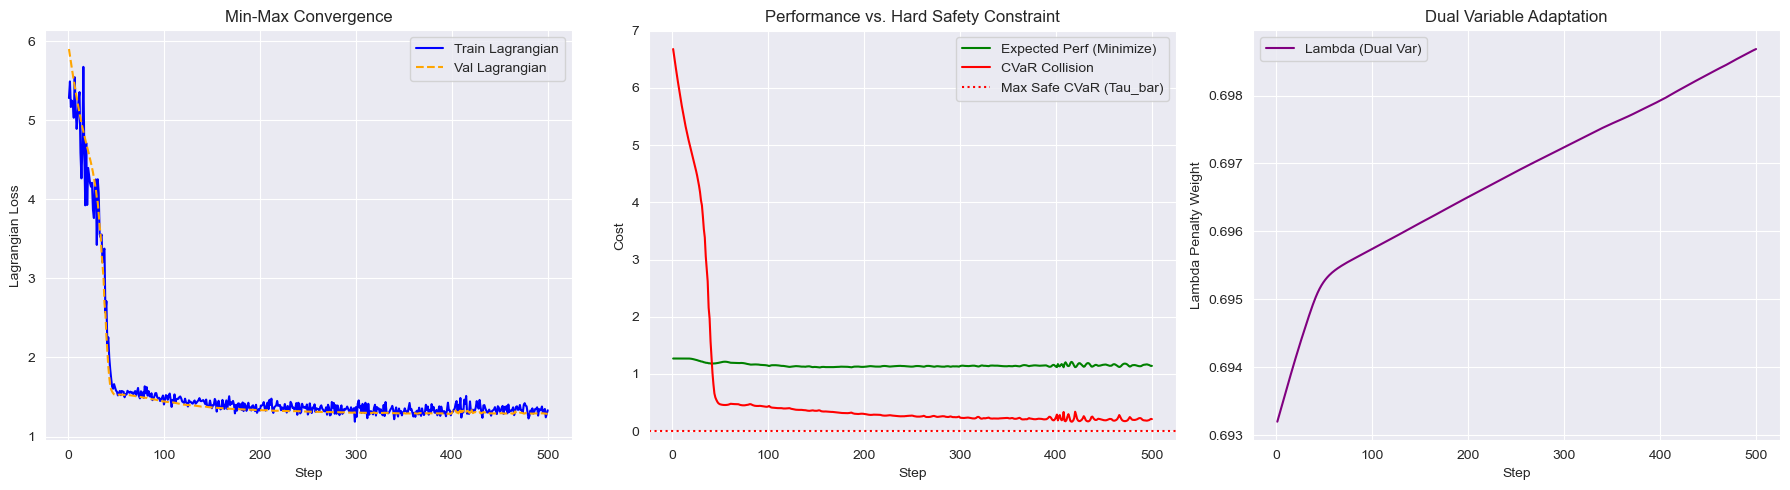

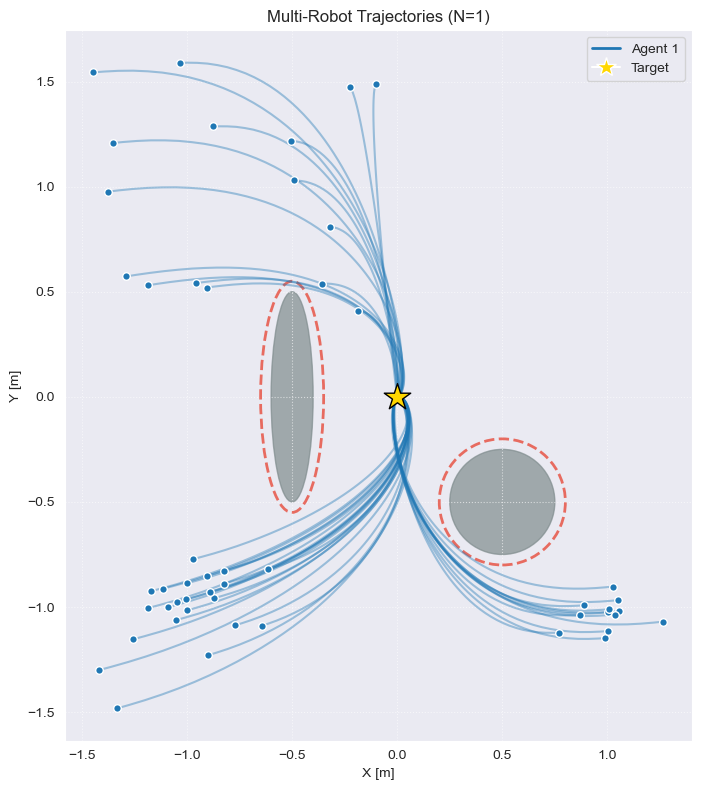

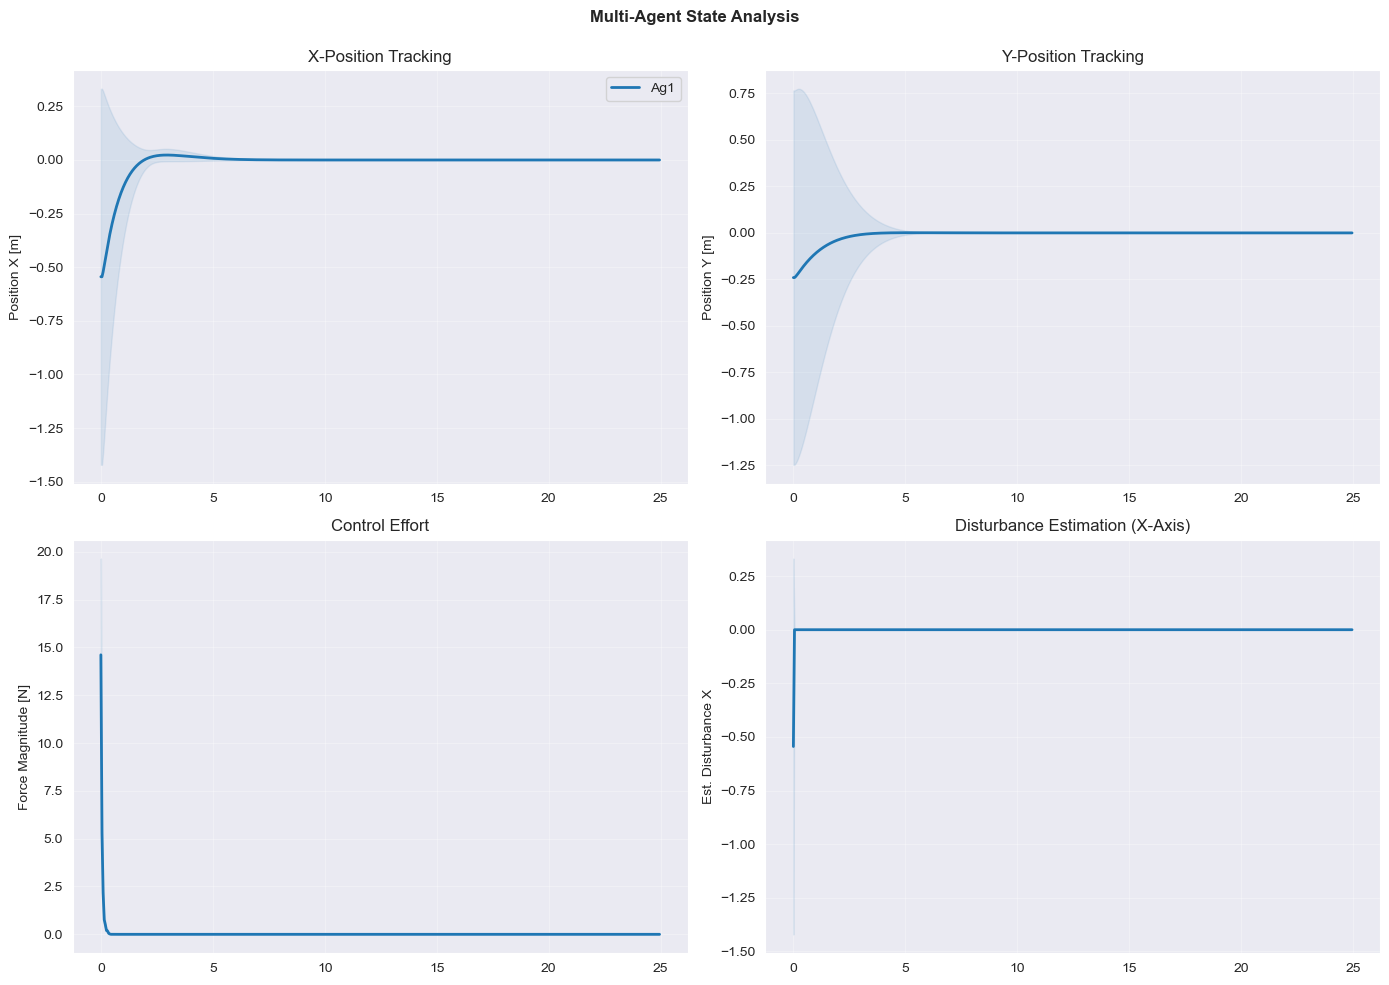

In [13]:
# ==========================================
# 1. Setup Metric and Wrapper
# ==========================================

metric = PBLoss(x_target, Q, R, lambda_obs, obs_centers, obs_radii_safe=obs_radii_safe, n_agents=n_agents, track_mode=track_mode, coll_mode = coll_mode)
metric.to(device)
loss_wrapper = HardConstraintCVaRLossWrapper(alpha=alpha_train, tau_safe_bar=tau_safe_bar, metric=metric)
loss_wrapper.to(device)

# ==========================================
# 2. Setup Primal and Dual Optimizers
# ==========================================
# Primal Optimizer: Minimizes controller weights and tau
# Primal Optimizer: Uses Parameter Groups to separate speeds
opt_primal = torch.optim.Adam([
    # Medium Speed: Controller weights
    {'params': PB_closed_loop_sim_lagrangian.parameters(), 'lr': lr},
    # Fast Speed: Tau needs to track the quantile quickly
    {'params': [loss_wrapper.tau], 'lr': lr * 10.0,}
])

# Dual Optimizer: Maximizes lambda (slightly higher LR??)
dual_params = [loss_wrapper.pre_lambda]
opt_dual = torch.optim.Adam(dual_params, lr=lr * 0.1, maximize=True)

# ==========================================
# 3. Training Loop setup
# ==========================================
# Lists for plotting
train_lagrangians = []
val_lagrangians = []
val_perfs = []
val_cvars = []
val_lambdas = []

last_traj_x_val = None
last_traj_u_val = None
last_traj_w_hat_val = None

print(f"Starting Formulation 3 Dual-Ascent training on {device}...")
pbar = tqdm(range(num_training_steps), desc="Hard Constrained Training")

for step in pbar:
    PB_closed_loop_sim_lagrangian.train()

    # Zero both optimizers
    opt_primal.zero_grad()
    opt_dual.zero_grad()

    batch_w = generate_random_batch(batch_size=batch_size, horizon=horizon, n_agents=n_agents,
                                    x0_centers=x0_centers, x0_stds=x0_stds, x0_probs=x0_probs,
                                    noise_std=noise_std, device=device)

    traj_x_train, traj_u_train, traj_w_hat_train = PB_closed_loop_sim_lagrangian.run(batch_w)

    # Forward pass
    lagrangian, _, _, _, _ = loss_wrapper(traj_x_train, traj_u_train)

    # Backward pass
    lagrangian.backward()

    # Step both optimizers
    opt_primal.step() # Steps in negative gradient direction
    opt_dual.step()   # Steps in positive gradient direction (because maximize=True)

    # ==========================================
    # 44. Validation and Logging
    # ==========================================
    if (step + 1) % log_interval == 0:
        PB_closed_loop_sim_lagrangian.eval()

        with torch.no_grad():
            traj_x_val, traj_u_val, traj_w_hat_val = PB_closed_loop_sim_lagrangian.run(fixed_val_w)
            val_lag, val_perf, val_cvar, val_lam, val_viol = loss_wrapper(traj_x_val, traj_u_val)

        train_lagrangians.append(lagrangian.item())
        val_lagrangians.append(val_lag.item())

        # FIX: val_perf is already a float, so just append it directly
        val_perfs.append(val_perf.item())
        val_cvars.append(val_cvar.item())
        val_lambdas.append(val_lam.item())

        # FIX: Remove .item() from val_perf here as well
        pbar.set_postfix({
            'Perf': f"{val_perf:.2f}",
            'CVaR Safe': f"{val_cvar:.2f}",
            'Viol': f"{val_viol:.2f}",
            'Lambda': f"{val_lam:.3f}"
        })


    if step == num_training_steps - 1:
        last_traj_x_val = traj_x_val.detach().cpu()
        last_traj_u_val = traj_u_val.detach().cpu()
        last_traj_w_hat_val = traj_w_hat_val.detach().cpu()

# ==========================================
# 5. Plotting Results
# ==========================================
steps = range(log_interval, num_training_steps + 1, log_interval)

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Lagrangian Loss
ax1.plot(steps, train_lagrangians, label='Train Lagrangian', color='blue')
ax1.plot(steps, val_lagrangians, label='Val Lagrangian', color='orange', linestyle='--')
ax1.set_xlabel('Step')
ax1.set_ylabel('Lagrangian Loss')
ax1.set_title('Min-Max Convergence')
ax1.legend()
ax1.grid(True)

# Plot 2: Performance vs Safety Constraint
ax2.plot(steps, val_perfs, label='Expected Perf (Minimize)', color='green')
ax2.plot(steps, val_cvars, label='CVaR Collision', color='red')
ax2.axhline(y=tau_safe_bar, color='red', linestyle=':', label='Max Safe CVaR (Tau_bar)')
ax2.set_xlabel('Step')
ax2.set_ylabel('Cost')
ax2.set_title('Performance vs. Hard Safety Constraint')
ax2.legend()
ax2.grid(True)

# Plot 3: Dual Variable (Lambda)
ax3.plot(steps, val_lambdas, label='Lambda (Dual Var)', color='purple')
ax3.set_xlabel('Step')
ax3.set_ylabel('Lambda Penalty Weight')
ax3.set_title('Dual Variable Adaptation')
ax3.legend()
ax3.grid(True)

plt.tight_layout()
plt.show()

plot_pb_trajectories(
    traj_x=last_traj_x_val,
    traj_u=last_traj_u_val,
    traj_w_hat=last_traj_w_hat_val,
    x_target=x_target,
    obs_centers=obs_centers,
    obs_radii=obs_radii,
    obs_radii_safe = obs_radii_safe,
    dt=dt
)

## Comparison test


--- Standard (Average) Controller Total cost ---
Mean Cost:       1.0778
95% Quantile:    2.0008
CVaR (Worst 5%): 2.5188
Absolute Worst:  3.9164

--- Standard (Average) Controller Collision avoidance cost ---
Mean Cost:       0.0421
95% Quantile:    0.2488
CVaR (Worst 5%): 0.3497
Absolute Worst:  0.6628

--- Robust (CVaR) Controller ---
Mean Cost:       1.1970
95% Quantile:    2.3389
CVaR (Worst 5%): 2.9286
Absolute Worst:  4.9167

--- Robust (CVaR) Controller Collision avoidance cost ---
Mean Cost:       0.0099
95% Quantile:    0.0557
CVaR (Worst 5%): 0.1745
Absolute Worst:  0.4420

--- Robust (CVaR) Controller ---
Mean Cost:       1.1926
95% Quantile:    2.3367
CVaR (Worst 5%): 2.9218
Absolute Worst:  4.9105

--- Robust (CVaR) Controller Collision avoidance cost ---
Mean Cost:       0.0116
95% Quantile:    0.0690
CVaR (Worst 5%): 0.1948
Absolute Worst:  0.4567



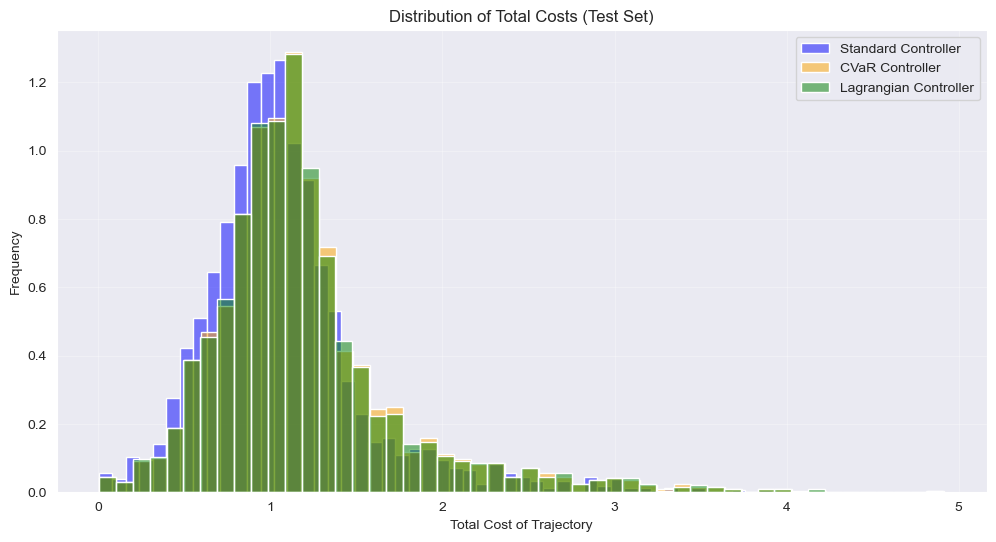

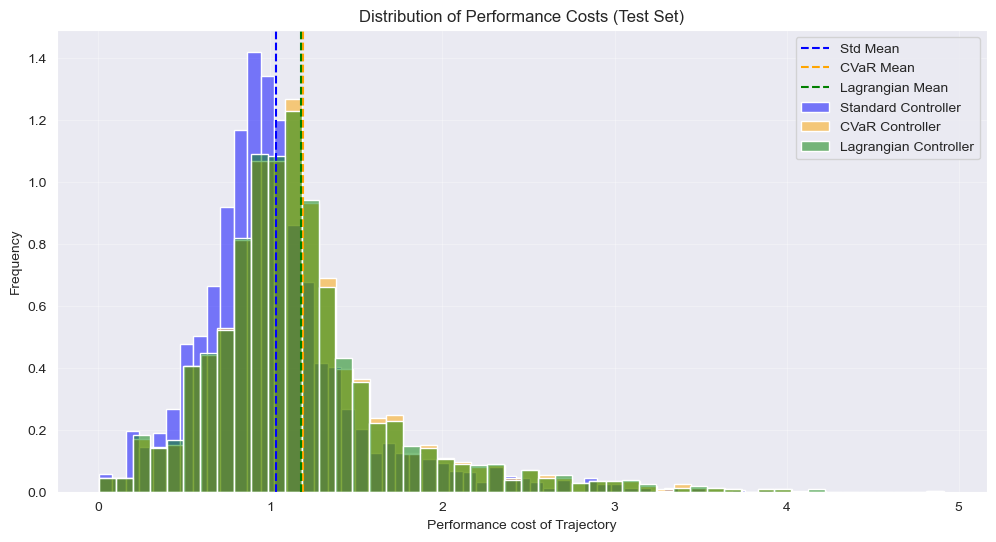

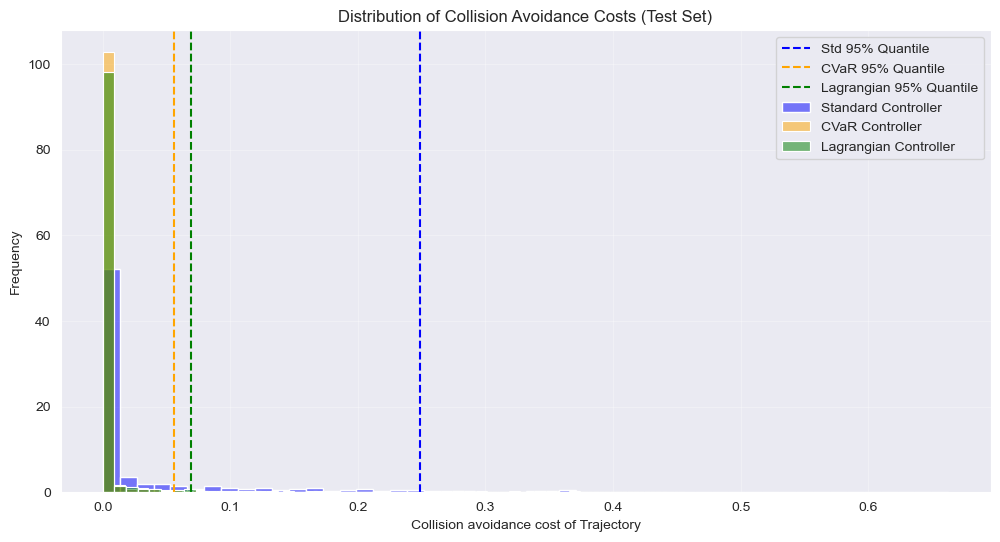

In [14]:
# 1. Generate a massive, fixed test set
test_w = generate_random_batch(batch_size = num_test_samples, horizon = horizon, n_agents= n_agents, x0_centers=x0_centers, x0_stds=x0_stds, x0_probs = x0_probs, noise_std = noise_std, device = device)
metric = PBLoss(x_target, Q, R, lambda_obs, obs_centers, obs_radii_safe=obs_radii_safe, n_agents=n_agents, track_mode=track_mode, coll_mode = coll_mode)
# 2. Evaluate Standard Controller
PB_closed_loop_sim.eval()
with torch.no_grad():
    traj_x_std, traj_u_std, _ = PB_closed_loop_sim.run(test_w)
    # Get the vector of costs (one per trajectory)
    costs_std, costs_std_x, costs_std_u, costs_std_coll = metric(traj_x_std, traj_u_std)
    costs_std = costs_std.cpu().numpy()
    costs_std_coll = costs_std_coll.cpu().numpy()
    costs_std_perf = (costs_std_x + costs_std_u).cpu().numpy()
# 3. Evaluate CVaR Controller
PB_closed_loop_sim_quantile.eval()
with torch.no_grad():
    traj_x_cvar, traj_u_cvar, _ = PB_closed_loop_sim_quantile.run(test_w)
    costs_cvar, costs_cvar_x, costs_cvar_u, costs_cvar_coll = metric(traj_x_cvar, traj_u_cvar)
    costs_cvar = costs_cvar.cpu().numpy()
    costs_cvar_coll = costs_cvar_coll.cpu().numpy()
    costs_cvar_perf = (costs_cvar_x + costs_cvar_u).cpu().numpy()
# 3. Evaluate lagrangian Controller
PB_closed_loop_sim_lagrangian.eval()
with torch.no_grad():
    traj_x_lag, traj_u_lag, traj_w_hat_lag = PB_closed_loop_sim_lagrangian.run(test_w)
    costs_lag, costs_lag_x, costs_lag_u, costs_lag_coll = metric(traj_x_lag, traj_u_lag)
    costs_lag = costs_lag.cpu().numpy()
    costs_lag_coll = costs_lag_coll.cpu().numpy()
    costs_lag_perf = (costs_lag_x + costs_lag_u).cpu().numpy()

# 4. Compute hard metrics
def print_metrics(name, costs, alpha=0.05):
    mean_cost = np.mean(costs)
    max_cost = np.max(costs)
    # The value below which 95% of the data falls
    quantile_95 = np.quantile(costs, 1 - alpha)
    # Average of the worst 5%
    cvar_95 = np.mean(costs[costs >= quantile_95])

    print(f"--- {name} ---")
    print(f"Mean Cost:       {mean_cost:.4f}")
    print(f"95% Quantile:    {quantile_95:.4f}")

    print(f"CVaR (Worst 5%): {cvar_95:.4f}")
    print(f"Absolute Worst:  {max_cost:.4f}\n")

print_metrics("Standard (Average) Controller Total cost", costs_std)
print_metrics("Standard (Average) Controller Collision avoidance cost", costs_std_coll)
print_metrics("Robust (CVaR) Controller", costs_cvar)
print_metrics("Robust (CVaR) Controller Collision avoidance cost", costs_cvar_coll)
print_metrics("Robust (CVaR) Controller", costs_lag)
print_metrics("Robust (CVaR) Controller Collision avoidance cost", costs_lag_coll)

# 5. Plot the Distribution of Total Costs
plt.figure(figsize=(12, 6))
sns.histplot(costs_std, color='blue', alpha=0.5, label='Standard Controller', bins=50, stat='density')
sns.histplot(costs_cvar, color='orange', alpha=0.5, label='CVaR Controller', bins=50, stat='density')
sns.histplot(costs_lag, color='green', alpha=0.5, label='Lagrangian Controller', bins=50, stat='density')


plt.title("Distribution of Total Costs (Test Set)")
plt.xlabel("Total Cost of Trajectory")
plt.ylabel("Frequency")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# 5. Plot the Distribution of Performance costs
plt.figure(figsize=(12, 6))
sns.histplot(costs_std_perf, color='blue', alpha=0.5, label='Standard Controller', bins=50, stat='density')
sns.histplot(costs_cvar_perf, color='orange', alpha=0.5, label='CVaR Controller', bins=50, stat='density')
sns.histplot(costs_lag_perf, color='green', alpha=0.5, label='Lagrangian Controller', bins=50, stat='density')

plt.axvline(np.mean(costs_std_perf), color='blue', linestyle='dashed', label='Std Mean')
plt.axvline(np.mean(costs_cvar_perf), color='orange', linestyle='dashed', label='CVaR Mean')
plt.axvline(np.mean(costs_lag_perf), color='green', linestyle='dashed', label='Lagrangian Mean')

plt.title("Distribution of Performance Costs (Test Set)")
plt.xlabel("Performance cost of Trajectory")
plt.ylabel("Frequency")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# 5. Plot the Distribution of Collision costs
plt.figure(figsize=(12, 6))
sns.histplot(costs_std_coll, color='blue', alpha=0.5, label='Standard Controller', bins=50, stat='density')
sns.histplot(costs_cvar_coll, color='orange', alpha=0.5, label='CVaR Controller', bins=50, stat='density')
sns.histplot(costs_lag_coll, color='green', alpha=0.5, label='Lagrangian Controller', bins=50, stat='density')

plt.axvline(np.quantile(costs_std_coll, 0.95), color='blue', linestyle='dashed', label='Std 95% Quantile')
plt.axvline(np.quantile(costs_cvar_coll, 0.95), color='orange', linestyle='dashed', label='CVaR 95% Quantile')
plt.axvline(np.quantile(costs_lag_coll, 0.95), color='green', linestyle='dashed', label='Lagrangian 95% Quantile')

plt.title("Distribution of Collision Avoidance Costs (Test Set)")
plt.xlabel("Collision avoidance cost of Trajectory")
plt.ylabel("Frequency")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [15]:
# The pure "Efficiency" or "Performance" is tracking + actuation
target_perf = (costs_lag_x + costs_lag_u).mean().item()

print(f"Lagrangian Cvar Controller Efficiency (Target Perf): {target_perf:.4f}")

Lagrangian Cvar Controller Efficiency (Target Perf): 1.1811


In [ ]:
import optuna

def objective_match_erm(trial):
    # 1. Suggest a lambda_obs (Log scale is crucial for penalty weights)
    lambda_obs_erm = trial.suggest_float("lambda_obs", 1.0, 5000.0, log=True)

    # 2. Re-initialize base loss and ERM wrapper with this specific lambda
    base_loss_erm = PBLoss(x_target, Q, R, lambda_obs_erm, obs_centers,
                           obs_radii_safe=obs_radii_safe, n_agents=n_agents,
                           track_mode=track_mode, coll_mode=coll_mode).to(device)
    loss_wrapper_erm = ERMWrapper(base_loss_erm)

    # 3. Initialize a fresh ERM Controller
    ren_erm = ContractiveREN(dim_in=state_dim*n_agents, dim_out=input_dim*n_agents,
                             dim_internal=dim_internal, dim_nl=dim_nl,
                             initialization_std=initialization_std).to(device) # Use your best init_std!
    PB_sim_erm = PBClosedLoop(ren_erm, f_sim, f_nom).to(device)

    optimizer_erm = torch.optim.Adam(PB_sim_erm.parameters(), lr=lr)

    # 4. Train the ERM controller
    PB_sim_erm.train()
    for step in range(num_training_steps): # Standard training loop
        optimizer_erm.zero_grad()
        batch_w = generate_random_batch(batch_size=batch_size, horizon=horizon, n_agents=n_agents,
                                        x0_centers=x0_centers, x0_stds=x0_stds, x0_probs=x0_probs,
                                        noise_std=noise_std, device=device)
        traj_x_train, traj_u_train, _ = PB_sim_erm.run(batch_w)
        loss, _, _, _ = loss_wrapper_erm(traj_x_train, traj_u_train)
        loss.backward()
        optimizer_erm.step()

    # 5. Evaluate the trained ERM on the FIXED validation set
    PB_sim_erm.eval()
    with torch.no_grad():
        traj_x_val, traj_u_val, _ = PB_sim_erm.run(test_w)
        _, cost_x_erm, cost_u_erm, _ = loss_wrapper_erm(traj_x_val, traj_u_val)
        current_perf = (cost_x_erm + cost_u_erm).item()

    # 6. We want to MINIMIZE the absolute difference to our target
    return abs(current_perf - target_perf)

print("--- Tuning ERM to match CVaR Efficiency ---")
study_match = optuna.create_study(direction="minimize", study_name="ERM_Matching")
study_match.optimize(objective_match_erm, n_trials=20)

print(f"Best matching lambda_obs: {study_match.best_params['lambda_obs']:.2f}")

[I 2026-02-27 20:03:41,939] A new study created in memory with name: ERM_Matching


--- Tuning ERM to match CVaR Efficiency ---


[I 2026-02-27 20:07:58,246] Trial 0 finished with value: 0.05973482131958008 and parameters: {'lambda_obs': 116.74990547271499}. Best is trial 0 with value: 0.05973482131958008.
[I 2026-02-27 20:12:51,958] Trial 1 finished with value: 0.21497976779937744 and parameters: {'lambda_obs': 1.4220546399633225}. Best is trial 0 with value: 0.05973482131958008.
[I 2026-02-27 20:17:56,207] Trial 2 finished with value: 0.21333611011505127 and parameters: {'lambda_obs': 2.223893941873853}. Best is trial 0 with value: 0.05973482131958008.
[I 2026-02-27 20:22:43,204] Trial 3 finished with value: 0.2146221399307251 and parameters: {'lambda_obs': 1.191247130842695}. Best is trial 0 with value: 0.05973482131958008.
[I 2026-02-27 20:27:12,990] Trial 4 finished with value: 0.04104268550872803 and parameters: {'lambda_obs': 1456.6096429287845}. Best is trial 4 with value: 0.04104268550872803.
[I 2026-02-27 20:31:49,659] Trial 5 finished with value: 0.15354454517364502 and parameters: {'lambda_obs': 46.71